In [1]:
# Package Imports - copy and paste
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

In [2]:
# Load the data - copy and paste
file_location = 'https://joannabieri.com/introdatascience/data/lego_sample.csv'
DF = pd.read_csv(file_location)

In [3]:
# Look at the data - copy and paste
(DF)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size
0,10859,My First Ladybird,DUPLO®,6,4.99,16.00,2018,Ages_1½-3,9,NaN,Box,NaN,5,Large
1,10860,My First Race Car,DUPLO®,6,4.99,9.45,2018,Ages_1½-3,9,NaN,Box,0.13Kg (0.29 lb),6,Large
2,10862,My First Celebration,DUPLO®,41,14.99,39.89,2018,Ages_1½-3,9,NaN,Box,NaN,18,Large
3,10864,Large Playground Brick Box,DUPLO®,71,49.99,56.69,2018,Ages_2-5,32,2.0,Plastic box,1.41Kg (3.11 lb),49,Large
4,10867,Farmers' Market,DUPLO®,26,19.99,36.99,2018,Ages_2-5,9,3.0,Box,NaN,18,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,60251,Monster Truck,City,55,9.99,8.99,2020,Ages_5+,32,1.0,Box,0.14Kg (0.31 lb),34,Small
71,60252,Construction Bulldozer,City,126,19.99,15.99,2020,Ages_4+,84,2.0,Box,0.35Kg (0.78 lb),81,Small
72,60258,Tuning Workshop,City,897,99.99,99.99,2020,Ages_6+,389,7.0,Box,1.63Kg (3.58 lb),411,Small
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small


In [4]:
# a. there are 14 variables and 75 observations
# b. the names of all the variables are item_number, set_name, theme, pieces, price, amazon_price, year, ages, pages, minifigures, packaging, weight, unique_pieces, size
# c. numerical: pieces (discrete), price (continuous), amazon_price (continous), year (discrete), pages (discrete), weight (continuous), unique_pieces (discrete)
# categorical: item_number (nominal), set_name (nominal), theme (nominal), ages (ordinal), minifigures (discrete), packaging (nominal), size (ordinal)
# d.
(DF).describe().round(2)

,item_number,pieces,price,amazon_price,year,pages,minifigures,unique_pieces
count,75.00,75.00,75.00,75.00,75.00,75.00,65.00,75.00
mean,37498.49,196.45,32.14,39.39,2019.05,73.21,2.62,96.67
std,20461.27,213.91,27.75,33.30,0.82,76.95,2.13,89.47
min,10859.00,6.00,4.99,6.29,2018.00,1.00,1.00,5.00
25%,10916.50,37.00,9.99,17.98,2018.00,14.00,1.00,30.00
50%,41378.00,93.00,19.99,29.99,2019.00,44.00,2.00,61.00
75%,60193.00,323.50,39.99,53.94,2020.00,116.00,3.00,151.00
max,60267.00,897.00,149.99,184.99,2020.00,389.00,15.00,411.00


In [5]:
# d.
#1 this data was recorded only from the years 2018-2020
#2 the minofigures column must have ten NaNs because there are only 65 total and the rest have 75
#3 for the pieces, the mean is 196 but the median is 93, suggesting that very few high count pices are skewing the mean upward
#4 there is an outlier in the minifigures, 15, because it is proportionally and significantly higher than the 75%

In [6]:
categories = ['set_name', 'theme', 'ages', 'minifigures', 'packaging', 'size']
DF_categories = DF[categories]
show(DF_categories)

Loading ITables v2.5.2 from the internet... (need help?)


In [7]:
counts = DF_categories['set_name'].value_counts()
show(counts)
# this was a stupid one to do the value counts to because there is only one of each

Loading ITables v2.5.2 from the internet... (need help?)


In [8]:
counts = DF_categories['ages'].value_counts()
show(counts)
# the Ages_6+ categry seems to be the most popular age target for these sets

Loading ITables v2.5.2 from the internet... (need help?)


In [9]:
counts = DF_categories['theme'].value_counts()
show(counts)
# interesting they probably took 25 of each theme on purpose since they all target different audiences

Loading ITables v2.5.2 from the internet... (need help?)


In [10]:
counts = DF_categories['minifigures'].value_counts()
show(counts)
# 1, 2, and 3 is the most popular amount of minifigures

Loading ITables v2.5.2 from the internet... (need help?)


In [11]:
counts = DF_categories['packaging'].value_counts()
show(counts)
# they are almost all in a box

Loading ITables v2.5.2 from the internet... (need help?)


In [12]:
counts = DF_categories['size'].value_counts()
show(counts)
# nice clean numbers and only two different counts

Loading ITables v2.5.2 from the internet... (need help?)


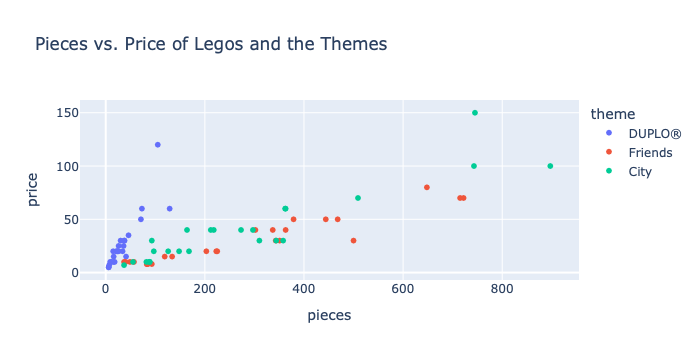

In [13]:
fig = px.scatter(DF,
                 x='pieces',
                 y='price',
                 color='theme',
                 title='Pieces vs. Price of Legos and the Themes',
hover_data='set_name')
fig.show()

In [14]:
# yes more expensive sets tend to have more pieces because if I were to draw a line that best suits the graph it would look like its projecting upward.
# the most expensive set lies at (745, 149.99) and is City theme and set_name is Ocean Exploring Ship.
# DUPLO seems to be the least amount of pieces and the lowest price. Friends looks maybe a little bit cheaper than City, whith City having simultaniously the sets with the most amount of pieces and the highest price.
# (105, 119.99), (745, 149.99), and maybe (897, 99.99) appear to be possible outliers.

In [15]:
DF['Price_Difference'] = DF['amazon_price'] - DF['price']
(DF['Price_Difference'])
# when the prices are positive this means that amazon charges more than retail

0     11.01
1      4.46
2     24.90
3      6.70
4     17.00
      ...  
70    -1.00
71    -4.00
72     0.00
73     0.00
74    -2.00
Name: Price_Difference, Length: 75, dtype: float64

In [16]:
grouped = DF.groupby('theme')['Price_Difference'].describe()
grouped.T
# I looked up how to flip the rows and the columns because I found it difficult to read.
# Amazon chargres more than retail on DUPLO and Friends more than City.
# Friends has the highest Amazon-to-retail margin at $115.
# Friends with greater standard deviation implies greater variability.
# I found it interesting thatall of thr medians are really similar but Friends has the highest max.

theme,City,DUPLO®,Friends
count,25.000000,25.000000,25.000000
mean,5.399600,7.392400,8.979200
std,15.243677,16.996152,24.047927
min,-13.990000,-5.000000,-9.990000
25%,-4.010000,-2.000000,-0.040000
50%,-1.000000,0.000000,3.960000
75%,12.000000,11.010000,8.940000
max,39.960000,69.000000,115.000000


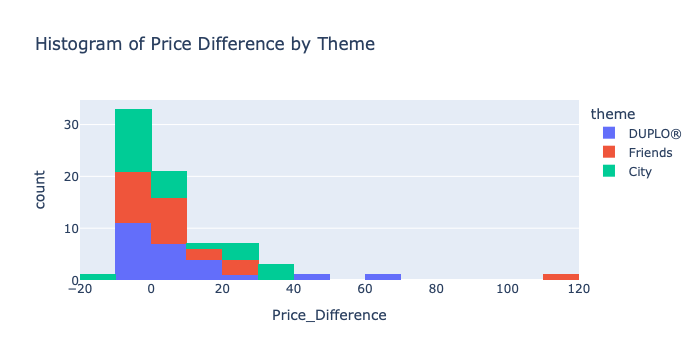

In [17]:
fig = px.histogram(DF,
             x='Price_Difference',
            color='theme',
            title='Histogram of Price Difference by Theme')
fig.update_traces(dict(marker_line_width=0))
fig.show()

In [18]:
mask = DF['price'] == DF['price'].max()
most_expensive_set_retail = DF[mask]
most_expensive_set_retail
# 745 pieces, $149.99 (price = amazon_price in this situation)

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,Price_Difference
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.0


In [19]:
mask = DF['amazon_price'] == DF['amazon_price'].max()
most_expensive_set_amazon = DF[mask]
most_expensive_set_amazon
# interesting there's a fat margin compared to when it was just price

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,Price_Difference
28,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,115.0


In [20]:
mask = (DF['price'] > 100) | (DF['amazon_price'] > 100)
above_100 = DF[mask]
above_100
# there are only three total

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,Price_Difference
7,10875,Cargo Train,DUPLO®,105,119.99,128.95,2018,Ages_2-5,64,3.0,Box,2.86Kg (6.31 lb),68,Large,8.96
28,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,115.00
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00


In [39]:
mean_LEGO_retail_amazon = DF[['year', 'price', 'amazon_price']].groupby('year').mean()
mean_LEGO_retail_amazon
# the price took a big jump of $10 from 2019-2020
# on average, the price of LEGOs went 1 cent less from 2018-2019, but ultimately increased over time

,price,amazon_price
year,,
2018,28.772609,52.639130
2019,28.670000,29.217600
2020,38.212222,37.532963


In [40]:
mean_pieces_retail_amazon = DF[['year', 'pieces']].groupby('year').mean()
mean_pieces_retail_amazon
# on average the number of pieces increased over the years

,pieces
year,
2018,157.913043
2019,193.120000
2020,232.370370


In [47]:
mask = DF['minifigures'] == DF['minifigures'].max()
most_minifigures = DF[mask]
most_minifigures
# the "People Pack - Outdoor Adventures" set had the most minifigures at15 minifigures
# there are 10 sets with either 0 or NaN minifigures


,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,Price_Difference
56,60202,People Pack - Outdoor Adventures,City,164,39.99,69.99,2018,Ages_5-12,64,15.0,Box,0.29Kg (0.64 lb),128,Small,30.0


In [48]:
zero_or_unknown = DF[(DF['minifigures'] == 0) | (DF['minifigures'] != DF['minifigures'])]
count_zero_unknown = zero_or_unknown.shape[0]
count_zero_unknown
# there are 10 sets with either 0 or NaN minifigures
# i was confused how to write the code so I tried to show the rows where the number of minifigures was missing

10

In [54]:
# 7
# on average the retail price is cheaper than the amazon price, so i would suggest shopping retail
mean_retail = DF[['price', 'minifigures', 'unique_pieces', 'pieces']].groupby('price').mean()
mean_retail

,minifigures,unique_pieces,pieces
price,,,
4.99,NaN,5.500000,6.000000
6.99,2.000000,17.500000,22.000000
7.99,1.250000,42.000000,86.000000
9.99,1.545455,34.461538,49.230769
14.99,1.333333,47.250000,77.500000
19.99,2.000000,58.769231,102.538462
24.99,1.500000,22.500000,31.000000
29.99,2.444444,115.900000,240.400000
34.99,2.000000,33.000000,46.000000


In [55]:
69.99 / 264.33

0.26478265804108503

In [56]:
69.99 / 648.666667

0.1078982527708642

In [57]:
99.99 / 354.500000

0.2820592383638928

In [58]:
99.99 / 820.000000

0.1219390243902439

In [59]:
7.99 / 42

0.19023809523809523

In [60]:
7.99 / 86

0.09290697674418605

In [61]:
# By looking at the prices, I have determined that a $7.99 set is the best bargain for the average number of pieces and unique pieces.
# It had the most amount of pieces and unique pieces for the cheapest amount of money.
# $0.19 per unique piece
# $0.09 per piece

In [66]:
# as a kid (yes I'm 21), I believe to get the biggest bang for your buck, prioritizing the amount of pieces you need to put the set together is important for utilizing much of your time
# I also think that unique pieces are a fun add on to most personalize the exclusivity of your set, as well as the experience you have building the set.

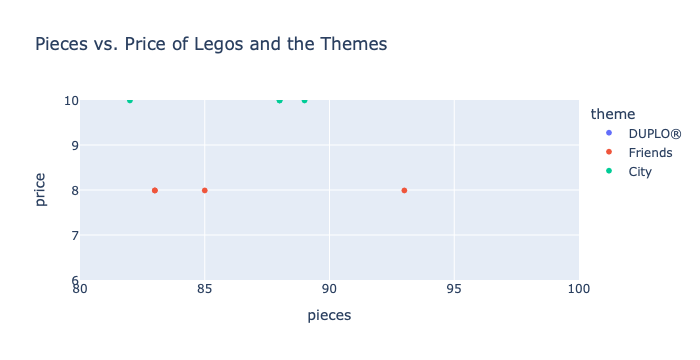

In [94]:
fig = px.scatter(DF,
                 x='pieces',
                 y='price',
                 color='theme',
                 title='Pieces vs. Price of Legos and the Themes',
hover_data=['set_name', 'ages', 'unique_pieces'],
range_x=[80, 100],
range_y=[6, 10])                

fig.show()
# By hovering over the three sets that cost $7.99, you can see the ages are all 6+ so perfect for your 6 year old cousin

In [96]:
DF['deal'] = DF['price'] == 7.99
DF['deal']

0     False
1     False
2     False
3     False
4     False
      ...  
70    False
71    False
72    False
73    False
74    False
Name: deal, Length: 75, dtype: bool

In [97]:
DF[DF['deal']]

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,Price_Difference,deal,best_deal
30,41356,Stephanie's Heart Box,Friends,85,7.99,14.99,2019,Ages_6+,32,1.0,NaN,0.13Kg (0.29 lb),36,Small,7.00,True,True
31,41358,Mia's Heart Box,Friends,83,7.99,18.64,2019,Ages_6+,32,1.0,NaN,0.14Kg (0.31 lb),38,Small,10.65,True,True
38,41384,Andrea's Summer Heart Box,Friends,83,7.99,14.99,2019,Ages_6+,36,1.0,Other,NaN,46,Small,7.00,True,True
39,41387,Olivia's Summer Heart Box,Friends,93,7.99,7.99,2019,Ages_6+,40,2.0,Other,NaN,48,Small,0.00,True,True


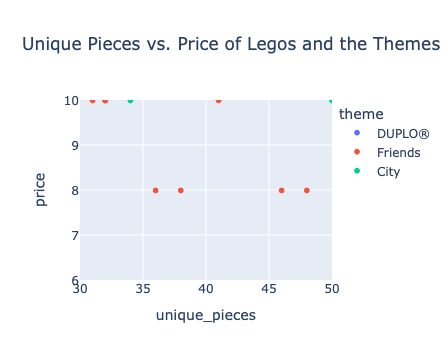

In [102]:
fig = px.scatter(DF,
                 x='unique_pieces',
                 y='price',
                 color='theme',
                 title='Unique Pieces vs. Price of Legos and the Themes',
hover_data=['set_name', 'ages', 'pieces'],
range_x=[30, 50],
range_y=[6, 10])                

fig.show()

# Very super interesting that when i found all of the best deals, there were four, not three.
# I noticed that two of them had the same amount of pieces, but a differemt amount of unique pieces.
# Because of this, I added a new and imwproved graph with the x axis changed to unique pieces, since there is an original number for each of those four.
# I went and changed my graph so I could see all four values.
# By hovering over the FOUR sets that cost $7.99, you can see the ages are all 6+ so perfect for your 6 year old cousin.